# Trader Performance vs Market Sentiment

## PrimeTrade.ai - Round 0 Assignment

**Candidate:** Anuj Chhaparwal

---

## Objective

The objective of this project is to analyze whether Bitcoin market sentiment (Fear & Greed Index) has any relationship with trader performance and trading behaviour on Hyperliquid.

In this notebook, I will:

- Load and inspect both datasets.
- Clean and prepare the data for analysis.
- Merge the datasets using the trading date.
- Calculate important trading metrics.
- Analyze how trader behaviour changes during Fear and Greed periods.
- Summarize the findings with charts and observations.
- Suggest a few practical strategies based on the analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Part A - Data Preparation

Before starting the analysis, I will first inspect both datasets to understand their structure and data quality.

The following checks will be performed:

- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Basic summary of the datasets

In [2]:
fear = pd.read_csv("../data/fear_greed_index.csv")

trade = pd.read_csv("../data/historical_data.csv")

In [3]:
print("Fear & Greed Dataset")
display(fear.head())

print("\nHistorical Trading Dataset")
display(trade.head())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Historical Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("Fear & Greed Shape :", fear.shape)
print("Historical Data Shape :", trade.shape)

Fear & Greed Shape : (2644, 4)
Historical Data Shape : (211224, 16)


In [5]:
print("Fear & Greed Info")
fear.info()

print("\nHistorical Data Info")
trade.info()

Fear & Greed Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Historical Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  obje

In [6]:
print("Fear & Greed Missing Values")
display(fear.isnull().sum())

print("\nHistorical Data Missing Values")
display(trade.isnull().sum())

Fear & Greed Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Historical Data Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
print("Fear Dataset Duplicates :", fear.duplicated().sum())

print("Trade Dataset Duplicates :", trade.duplicated().sum())

Fear Dataset Duplicates : 0
Trade Dataset Duplicates : 0


In [8]:
display(fear.describe(include="all"))

display(trade.describe(include="all"))

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [9]:
print("Fear Columns")

print(fear.columns.tolist())

print("\nTrade Columns")

print(trade.columns.tolist())

Fear Columns
['timestamp', 'value', 'classification', 'date']

Trade Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


## Data Cleaning

Before combining the datasets, I will check the date columns and convert them into a common format. This will make it easier to merge the datasets and compare trading activity with the corresponding market sentiment.

In [10]:
print("Fear & Greed Columns")
print(fear.columns)

print("\nTrade Columns")
print(trade.columns)

Fear & Greed Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trade Columns
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:
print(fear["date"].head())

print()

print(trade["Timestamp IST"].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object


In [12]:
# Fear & Greed dataset
fear['date'] = pd.to_datetime(fear['date'], format='mixed', dayfirst=True)

# Historical dataset
trade['Timestamp IST'] = pd.to_datetime(
    trade['Timestamp IST'],
    format='mixed',
    dayfirst=True
)

# Extract only the date
fear['date'] = fear['date'].dt.date
trade['date'] = trade['Timestamp IST'].dt.date

## Merge Datasets

The trader dataset is merged with the Fear & Greed Index using the common trading date so that every trade is associated with the market sentiment of that day.

In [13]:
merged = trade.merge(
    fear[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print(merged.shape)

merged.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [14]:
merged[['classification','value']].isnull().sum()

classification    6
value             6
dtype: int64

## Feature Engineering

Creating additional metrics required for analysis.

In [15]:
# Profit or Loss

merged["Profit"] = merged["Closed PnL"] > 0

# Trade Date

merged["Trade_Date"] = pd.to_datetime(merged["date"])

# Trade Size

merged["Trade_Size"] = merged["Size USD"]



In [16]:
sentiment_summary = merged.groupby("classification").agg(

    Total_PnL=("Closed PnL","sum"),

    Average_PnL=("Closed PnL","mean"),

    Win_Rate=("Profit","mean"),

    Average_Trade_Size=("Size USD","mean"),

    Number_of_Trades=("Account","count")

)

long_short = pd.crosstab(
    merged["classification"],
    merged["Direction"]
)

sentiment_summary["Open_Long_Trades"] = long_short.get("Open Long", 0)
sentiment_summary["Open_Short_Trades"] = long_short.get("Open Short", 0)

sentiment_summary["Long_Short_Ratio"] = (
    sentiment_summary["Open_Long_Trades"] /
    sentiment_summary["Open_Short_Trades"].replace(0, np.nan)
)

sentiment_summary

,Total_PnL,Average_PnL,Win_Rate,Average_Trade_Size,Number_of_Trades,Open_Long_Trades,Open_Short_Trades,Long_Short_Ratio
classification,,,,,,,,
Extreme Fear,7.391102e+05,34.537862,0.370607,5349.731843,21400,7005,3174,2.206994
Extreme Greed,2.715171e+06,67.892861,0.464943,3112.251565,39992,6300,7663,0.822132
Fear,3.357155e+06,54.290400,0.420768,7816.109931,61837,17824,10887,1.637182
Greed,2.150129e+06,42.743559,0.384828,5736.884375,50303,8544,11664,0.732510
Neutral,1.292921e+06,34.307718,0.396991,4782.732661,37686,10222,6353,1.609004


In [17]:
daily_metrics = merged.groupby("date").agg(

    Daily_PnL=("Closed PnL","sum"),

    Trades=("Account","count"),

    Avg_Trade_Size=("Size USD","mean"),

    Win_Rate=("Profit","mean")

).reset_index()

daily_metrics.head()

,date,Daily_PnL,Trades,Avg_Trade_Size,Win_Rate
0,2023-05-01,0.000000,3,159.000000,0.000000
1,2023-12-05,0.000000,9,5556.203333,0.000000
2,2023-12-14,-205.434737,11,10291.213636,0.363636
3,2023-12-15,-24.632034,2,5304.975000,0.000000
4,2023-12-16,0.000000,3,5116.256667,0.000000


## Analysis 1: Performance During Fear vs Greed

This analysis compares trader performance across different market sentiment conditions.

Metrics evaluated:

- Average PnL
- Median PnL
- Win Rate
- Drawdown Proxy
- Trade Count

A boxplot is also used to visualize the distribution of trader profits and losses across sentiment categories.

In [18]:
performance = merged.groupby("classification").agg(
    Average_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Win_Rate=("Profit", "mean"),
    Drawdown_Proxy=("Closed PnL", lambda x: x[x < 0].sum()),
    Trade_Count=("Closed PnL", "count")
)

performance.round(2)

,Average_PnL,Median_PnL,Win_Rate,Drawdown_Proxy,Trade_Count
classification,,,,,
Extreme Fear,34.54,0.0,0.37,-636321.58,21400
Extreme Greed,67.89,0.0,0.46,-270899.93,39992
Fear,54.29,0.0,0.42,-593593.84,61837
Greed,42.74,0.0,0.38,-1058685.92,50303
Neutral,34.31,0.0,0.40,-389285.66,37686


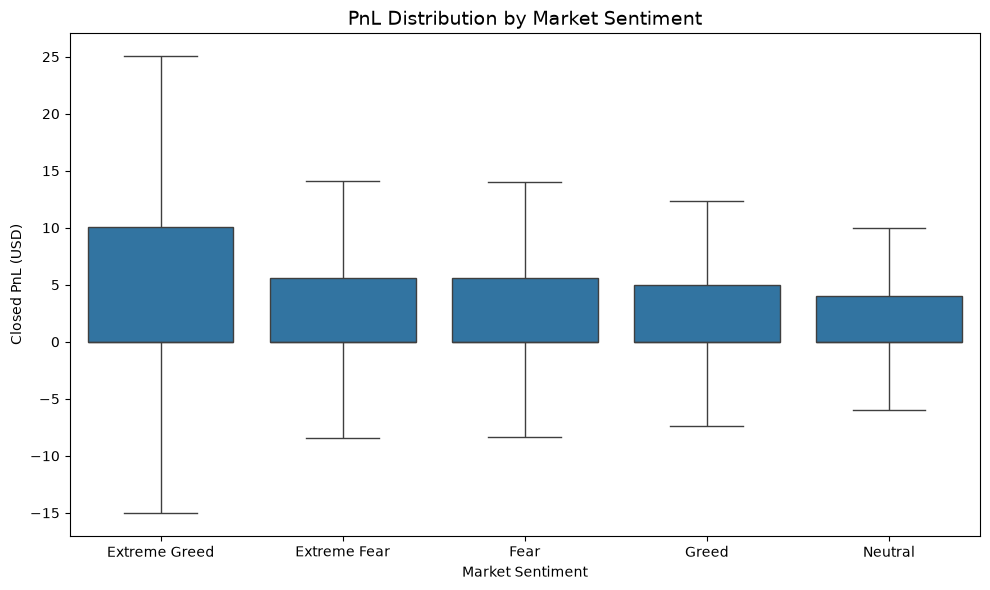

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    showfliers=False
)

plt.title("PnL Distribution by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (USD)")

plt.tight_layout()
plt.savefig("../charts/pnl_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

- **Extreme Greed** days recorded the highest average PnL (**67.89 USD**) and the highest win rate (**46%**), suggesting that traders generally achieved better performance during periods of strong market optimism.
- **Fear** days also produced relatively high average profitability (**54.29 USD**), indicating that some traders were able to capitalize on market corrections.
- **Greed** days exhibited the largest **drawdown proxy (-1,058,685.92 USD)**, implying that optimistic market conditions were also associated with the greatest cumulative downside risk.
- Although the average PnL differs across sentiment categories, the **median PnL remains 0** throughout, indicating that the majority of trades generated only small gains or losses, while a relatively small number of large trades influenced the averages.
- The boxplot shows that the central distribution of trade outcomes is broadly similar across sentiment categories, suggesting that differences in average profitability are primarily driven by larger winning or losing trades rather than consistent shifts in the typical trade outcome.

## Analysis 2: Trader Behaviour Across Market Sentiment

This analysis examines whether trader behaviour changes under different market sentiment conditions.

The following behavioural metrics are evaluated:

- Trade Frequency
- Position Size
- Long/Short Bias

> **Note:** Although the dataset contains a `Leverage` column, the recorded values contain unrealistic magnitudes (including large negative values), suggesting that the field is either encoded differently or requires additional documentation. Therefore, leverage is excluded from the behavioural comparison to avoid drawing unsupported conclusions.

In [20]:
behaviour = merged.groupby("classification").agg(
    Trade_Frequency=("Account", "count"),
    Average_Position_Size=("Size USD", "mean"),
    Median_Position_Size=("Size USD", "median")
)

behaviour.round(2)

,Trade_Frequency,Average_Position_Size,Median_Position_Size
classification,,,
Extreme Fear,21400,5349.73,766.15
Extreme Greed,39992,3112.25,500.05
Fear,61837,7816.11,735.96
Greed,50303,5736.88,555.00
Neutral,37686,4782.73,547.66


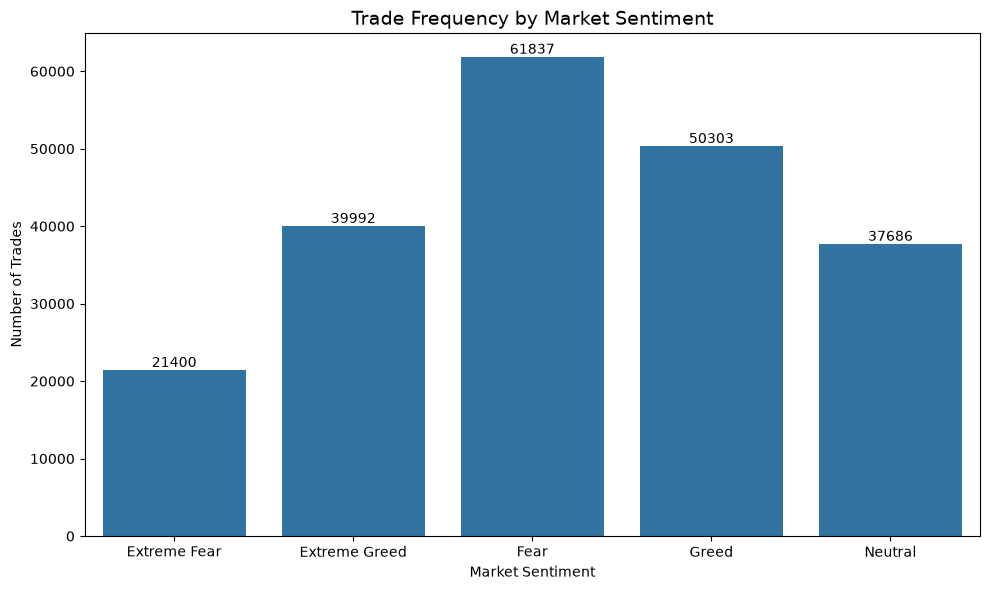

In [21]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=behaviour.reset_index(),
    x="classification",
    y="Trade_Frequency"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Trade Frequency by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.savefig("../charts/trade_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

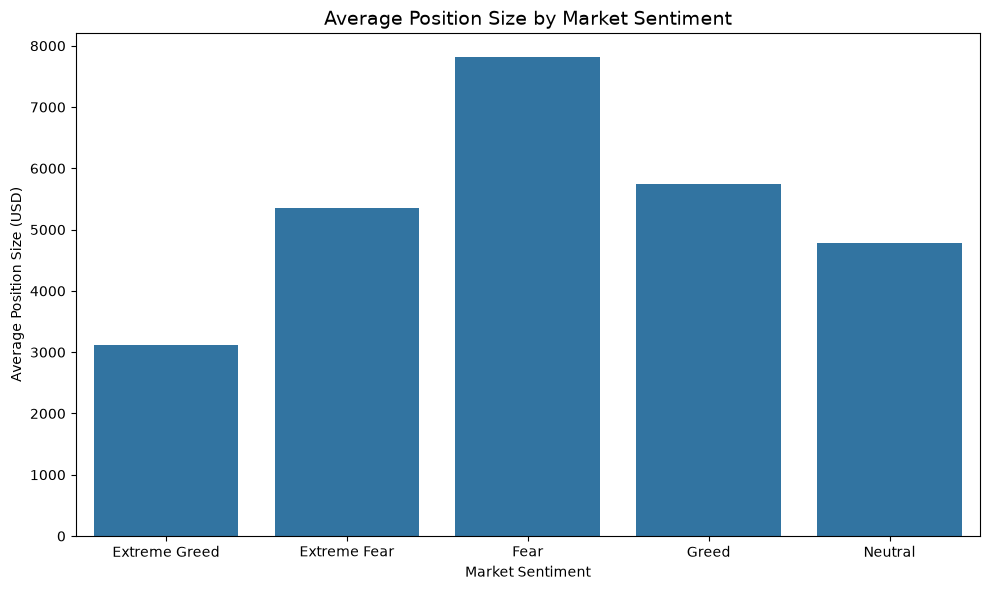

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=merged,
    x="classification",
    y="Size USD",
    estimator="mean",
    errorbar=None
)

plt.title("Average Position Size by Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.tight_layout()
plt.savefig("../charts/position_size.png", dpi=300, bbox_inches="tight")
plt.show()

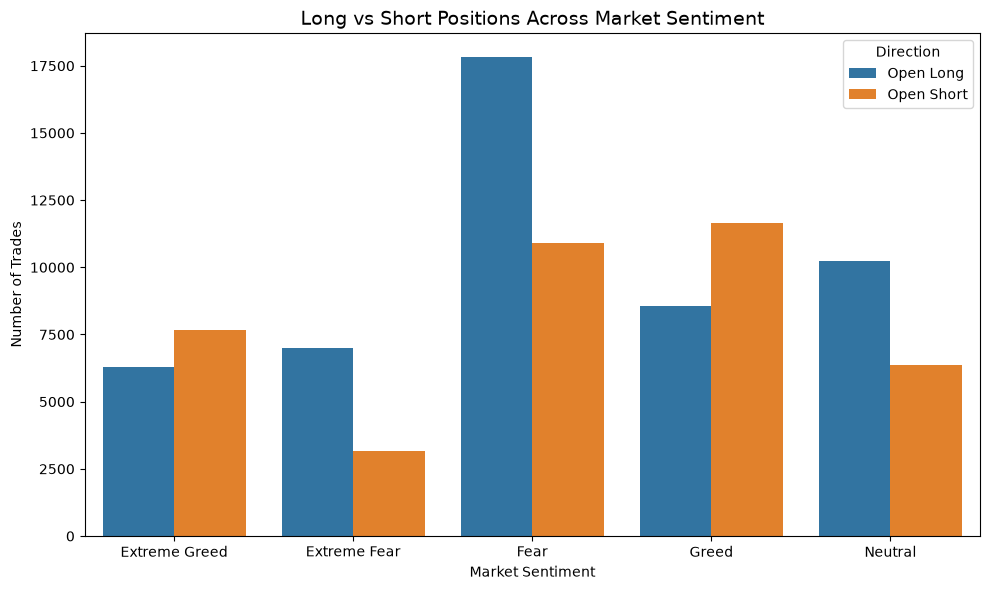

In [23]:
long_short = merged[
    merged["Direction"].isin(["Open Long", "Open Short"])
]

plt.figure(figsize=(10,6))

sns.countplot(
    data=long_short,
    x="classification",
    hue="Direction"
)

plt.title("Long vs Short Positions Across Market Sentiment", fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.savefig("../charts/long_vs_short.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

- Trading activity varied noticeably across different market sentiment conditions. **Fear** periods recorded the highest number of trades (**61,837**), while **Extreme Fear** periods recorded the fewest (**21,400**), suggesting that traders were more active during moderate market uncertainty than during extreme pessimism.
- The **largest average position size** was observed during **Fear** periods (**7,816.11 USD**), indicating that traders allocated more capital when market sentiment was negative. In contrast, **Extreme Greed** periods had the smallest average position size (**3,112.25 USD**).
- The **Long vs Short** analysis shows a clear change in trading direction with market sentiment. During **Fear** periods, traders opened substantially more **Long** positions than **Short** positions, whereas **Greed** periods exhibited a higher number of **Short** positions than **Long** positions.
- These findings suggest that **market sentiment influences trader behaviour**, particularly in terms of trading activity, capital allocation, and directional bias.
- Although the dataset contains a **Leverage** column, the recorded values contain unrealistic magnitudes (including very large negative values). Since the dataset documentation does not explain this field, leverage was excluded from the behavioural analysis to avoid drawing unsupported conclusions.

## Analysis 3: Trader Segmentation

To better understand differences in trader behavior and performance, traders are segmented based on their trading activity and profitability.

The following segments are analyzed:

- Frequent vs Infrequent Traders
- Consistent Winners vs Inconsistent Traders

In [24]:
trader_activity = merged.groupby("Account").agg(
    Total_Trades=("Closed PnL", "count"),
    Total_PnL=("Closed PnL", "sum"),
    Average_PnL=("Closed PnL", "mean"),
    Win_Rate=("Profit", "mean")
).reset_index()

In [25]:
median_trades = trader_activity["Total_Trades"].median()

trader_activity["Activity_Segment"] = np.where(
    trader_activity["Total_Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

In [26]:
activity_summary = trader_activity.groupby("Activity_Segment").agg(
    Average_Trades=("Total_Trades", "mean"),
    Average_PnL=("Average_PnL", "mean"),
    Average_Win_Rate=("Win_Rate", "mean")
)

activity_summary.round(2)

,Average_Trades,Average_PnL,Average_Win_Rate
Activity_Segment,,,
Frequent,11684.81,57.58,0.41
Infrequent,1516.69,137.80,0.39


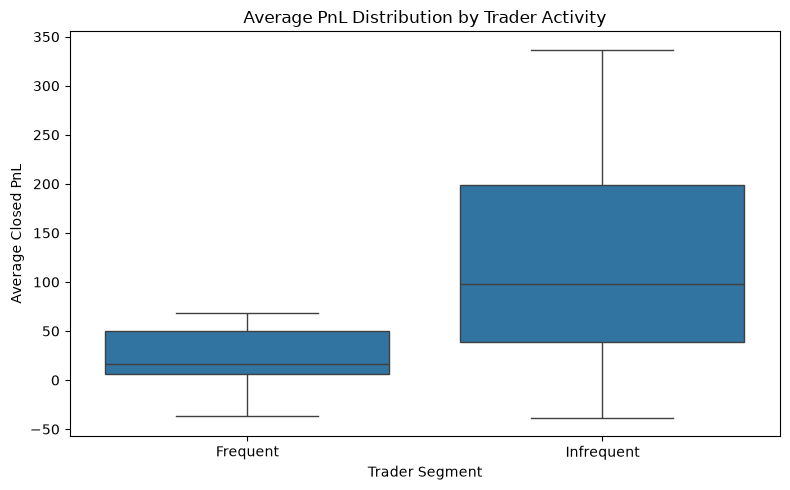

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=trader_activity,
    x="Activity_Segment",
    y="Average_PnL",
    showfliers=False
)

plt.title("Average PnL Distribution by Trader Activity")
plt.xlabel("Trader Segment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.savefig("../charts/trader_activity.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
trader_activity["Performance_Segment"] = np.where(
    trader_activity["Win_Rate"] >= 0.50,
    "Consistent Winner",
    "Inconsistent"
)

In [29]:
performance_segment = trader_activity.groupby("Performance_Segment").agg(
    Number_of_Traders=("Account", "count"),
    Average_PnL=("Average_PnL", "mean"),
    Average_Trades=("Total_Trades", "mean")
)

performance_segment.round(2)

,Number_of_Traders,Average_PnL,Average_Trades
Performance_Segment,,,
Consistent Winner,3,88.36,4516.33
Inconsistent,29,98.65,6816.38


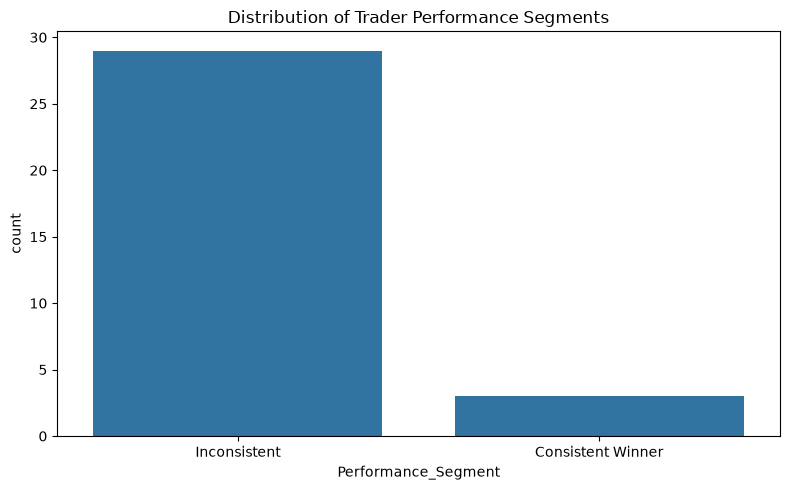

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trader_activity,
    x="Performance_Segment"
)

plt.title("Distribution of Trader Performance Segments")

plt.tight_layout()
plt.savefig("../charts/performance_segments.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

- Traders were segmented based on their trading activity and historical win rate to better understand behavioural differences.
- **Frequent traders** executed an average of **11,684.81 trades**, compared to **1,516.69 trades** for **Infrequent traders**, confirming a clear difference in trading activity.
- Despite trading less frequently, **Infrequent traders achieved a higher average PnL (137.80 USD)** than **Frequent traders (57.58 USD)**. This suggests that executing more trades does not necessarily translate into higher profitability per trade.
- The average win rates of Frequent (**41%**) and Infrequent (**39%**) traders were relatively similar, indicating that trading frequency alone had little impact on trading success.
- Only **3 out of 32 traders** achieved a win rate of at least **50%**, while **29 traders** were classified as inconsistent. This suggests that consistently profitable trading was relatively uncommon within the dataset.
- Overall, the segmentation indicates that trading quality may be more important than trading quantity, as higher activity did not correspond to higher average profitability.

# Part C - Actionable Output

Based on the analyses conducted above, the following strategy recommendations are proposed.

## Strategy Recommendation 1: Increase Position Selectivity During Fear Periods

The analysis shows that **Fear** periods generated the highest trading activity and the largest average position sizes. While average profitability remained relatively strong, increased trading activity can also expose traders to unnecessary risk.

**Rule of Thumb**

- During **Fear** periods, prioritize high-confidence trade setups rather than increasing the number of trades.
- Maintain disciplined position sizing and avoid overtrading simply because market volatility is higher.

## Strategy Recommendation 2: Focus on Trade Quality Instead of Trade Quantity

Trader segmentation revealed that **Infrequent traders achieved a higher average PnL per trade than Frequent traders**, despite executing significantly fewer trades.

**Rule of Thumb**

- Avoid increasing trade frequency without a clear trading edge.
- Emphasize trade selection and risk management over the number of trades executed, as higher activity alone did not result in better average profitability.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader behavior using the Fear & Greed Index and Hyperliquid historical trading data.

The analysis revealed that market sentiment influences both trader performance and trading behavior. Extreme Greed periods showed the highest average profitability and win rate, while Fear periods were associated with the highest trading activity and largest average position sizes. The Long vs Short analysis also demonstrated that traders adjusted their directional bias depending on market sentiment.

Trader segmentation further showed that executing a larger number of trades did not necessarily result in higher profitability. Infrequent traders achieved higher average PnL despite placing significantly fewer trades, highlighting the importance of trade quality over trade quantity.

Overall, the findings suggest that combining market sentiment with trader behavior can provide valuable insights for improving trading strategies and risk management.